# Getting started with Dataset

In [1]:
import numpy as np
import IPython
import matplotlib.pyplot as plt

import megamicros
from megamicros.log import log
from megamicros.ailab.dataset import AidbDataset

log.setLevel( "WARNING" )
#log.setLevel( "INFO" )
print( f"megamicros-{megamicros.__version__}" )


megamicros-2.0.45


In [2]:
# Plot spectrogram

def plot_specgram(waveform, sample_rate, title="Spectrogram"):
    waveform = waveform.numpy()

    figure, ax = plt.subplots()
    ax.specgram(waveform[0], Fs=sample_rate)
    figure.suptitle(title)
    figure.tight_layout()

In [3]:
# Set database access credentials
DBHOST = 'http://dbwelfare.biimea.io/'
#DBHOST = 'http://dbchantier.biimea.io/'
LOGIN = 'ailab'
EMAIL = 'bruno.gas@biimea.com'
PASSWORD = '#T;uZnQ5UJ_JC~&'

LABELS = 'sow-grunt-mod-stress'
LABELS = (1, 2, 3)
dataset = AidbDataset( '/Users/brunogas/Data/dataset/assets', DBHOST, labels=LABELS, channels=[1,2], download=True )

print( f"Number of extracted samples in database: {len( dataset )}" )

# extract data and print their shape
#for data_idx, [data, sample_rate, label] in enumerate( dataset ):
#    print( f"Extracted [{data_idx}] signal (label:{label}, sr={sample_rate}) of shape: {np.shape( data )}" )

0%
10%
20%
30%
40%
50%
60%
70%
80%
90%
100%
Number of extracted samples in database: 100


In [ ]:
import os
import torchaudio
_SAMPLE_DIR = "_assets"
YESNO_DATASET_PATH = os.path.join(_SAMPLE_DIR, "yes_no")
os.makedirs(YESNO_DATASET_PATH, exist_ok=True)

dataset = torchaudio.datasets.YESNO(YESNO_DATASET_PATH, download=True)

wavform tensor shape: torch.Size([2, 36699]) (datatype: torch.float32, device:cpu)
sample rate: 10000 Hz, label: 1


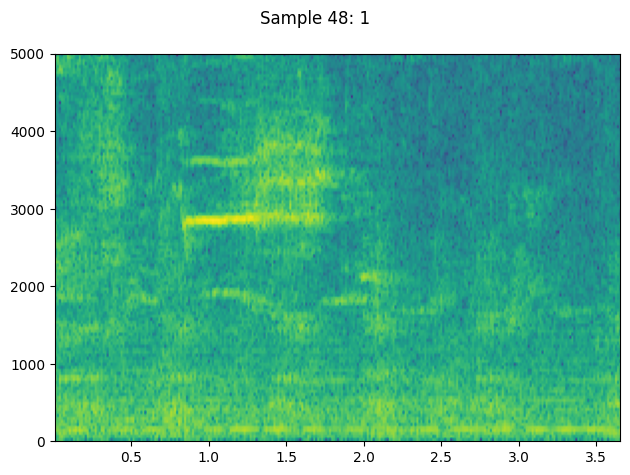

In [4]:
i = 48
waveform, label, sample_rate = dataset[i]
print( f"wavform tensor shape: {waveform.shape} (datatype: {waveform.dtype}, device:{waveform.device})" )
print( f"sample rate: {sample_rate} Hz, label: {label}")

plot_specgram( waveform, sample_rate, title=f"Sample {i}: {label}" )
IPython.display.Audio(waveform, rate=sample_rate)


## Preparing data for training with DataLoaders

In [5]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

## Iterate through the DataLoader

In [6]:
features, labels = next(iter( dataloader ) )
print(f"Feature batch shape: {features.size()}")
print(f"First sample label is: {labels[0]}")

RuntimeError: stack expects each tensor to be equal size, but got [2, 32399] at entry 0 and [2, 49592] at entry 1